# MatNet Parameter-Budget Comparison

This notebook compares MatNet models across matrix sizes `n in {1, 2, 4, 8, 16, 32}` under a target parameter budget of **20k-30k**.

It also builds a **traditional MLP baseline** whose parameter count is exactly matched to the selected **MatNet `n=1`** architecture.

The notebook does four things:

1. Loads a small classification task with 4 input features so large `n` values still fit the budget.
2. Searches for MatNet architectures that land inside the 20k-30k parameter range.
3. Trains all selected models and reports accuracy.
4. Plots parameter counts, accuracies, parameter-vs-accuracy, and training curves.

In [5]:
from __future__ import annotations

import itertools
import math
import sys
from pathlib import Path

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import optax
import pandas as pd
from flax import linen as nn
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

ROOT = Path.cwd().resolve()
if not (ROOT / 'matnet').exists() and (ROOT.parent / 'matnet').exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from matnet.models.builder import MatrixNetwork

## Dataset

Iris is used here because it has **4 features**, which makes it feasible to compare even `n = 32` under the same parameter budget.

In [6]:
data = load_iris()
X = data.data.astype(np.float32)
y = data.target.astype(np.int32)
class_names = data.target_names

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y,
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train).astype(np.float32)
X_test = scaler.transform(X_test).astype(np.float32)

num_classes = len(np.unique(y))
input_dim = X_train.shape[1]

print(f'Train shape: {X_train.shape}')
print(f'Test shape: {X_test.shape}')
print(f'Classes: {class_names}')

Train shape: (112, 4)
Test shape: (38, 4)
Classes: ['setosa' 'versicolor' 'virginica']


## Traditional Baseline

To make the **traditional MLP** exactly match the selected **MatNet `n=1`** parameter count, it includes an initial width-`1` dense layer. That mirrors the `InputScaling` stage of MatNet when `n = 1`.

Normalization is disabled for the sweep so the `n=1` MatNet and traditional baseline can be matched exactly.

In [7]:
class TraditionalMLP(nn.Module):
    hidden_dims: tuple[int, ...]
    output_dim: int
    dtype: jnp.dtype = jnp.float32

    @nn.compact
    def __call__(self, x: jnp.ndarray) -> jnp.ndarray:
        for width in self.hidden_dims:
            x = nn.Dense(width, dtype=self.dtype)(x)
            x = nn.relu(x)
        x = nn.Dense(self.output_dim, dtype=self.dtype)(x)
        return x

## Parameter Counting And Architecture Search

The search is done over **1 to 4 hidden layers**. The goal is to find one architecture per `n` that lands inside the **20k-30k** range and is as close as possible to the midpoint.

In [8]:
TARGET_MIN = 20_000
TARGET_MAX = 30_000
TARGET_MID = 25_000
N_VALUES = [1, 2, 4, 8, 16, 32]

WIDTH_CANDIDATES = {
    1:  [12, 16, 20, 24, 28, 32, 40, 48, 64, 80, 96, 128, 160],
    2:  [8, 12, 16, 20, 24, 28, 32, 40, 48, 64, 80],
    4:  [6, 8, 10, 12, 16, 20, 24, 28, 32, 40],
    8:  [4, 6, 8, 10, 12, 16, 20, 24, 28, 32],
    16: [2, 3, 4, 5, 6, 8, 10, 12, 16, 20],
    32: [1, 2, 3, 4, 5, 6, 8, 10],
}


def count_params(variables) -> int:
    return int(sum(x.size for x in jax.tree_util.tree_leaves(variables)))


def count_matnet_params(n: int, hidden_dims: tuple[int, ...], *, use_bias: bool = True) -> int:
    model = MatrixNetwork(
        matrix_size=n,
        hidden_dims=hidden_dims,
        output_dim=num_classes,
        use_bias=use_bias,
        use_input_scaling=True,
        use_normalization=False,
    )
    params = model.init(jax.random.PRNGKey(0), jnp.ones((1, input_dim), dtype=jnp.float32))
    return count_params(params)


def count_traditional_params(hidden_dims: tuple[int, ...]) -> int:
    model = TraditionalMLP(hidden_dims=hidden_dims, output_dim=num_classes)
    params = model.init(jax.random.PRNGKey(0), jnp.ones((1, input_dim), dtype=jnp.float32))
    return count_params(params)


def search_matnet_architecture(n: int) -> tuple[tuple[int, ...], int]:
    candidates = WIDTH_CANDIDATES[n]
    best = None
    for depth in range(1, 5):
        for hidden_dims in itertools.product(candidates, repeat=depth):
            param_count = count_matnet_params(n, hidden_dims)
            in_budget = TARGET_MIN <= param_count <= TARGET_MAX
            score = (
                0 if in_budget else 1,
                abs(param_count - TARGET_MID),
                -depth,
                hidden_dims,
            )
            if best is None or score < best[0]:
                best = (score, tuple(hidden_dims), param_count)
    return best[1], best[2]


selected_architectures = {}
for n in N_VALUES:
    hidden_dims, param_count = search_matnet_architecture(n)
    selected_architectures[n] = {
        'hidden_dims': hidden_dims,
        'param_count': param_count,
    }

arch_df = pd.DataFrame(
    [
        {
            'model': f'MatNet n={n}',
            'n': n,
            'hidden_dims': selected_architectures[n]['hidden_dims'],
            'param_count': selected_architectures[n]['param_count'],
        }
        for n in N_VALUES
    ]
)
arch_df

,model,n,hidden_dims,param_count
0,MatNet n=1,1,"(24, 160, 80, 96)",25000
1,MatNet n=2,2,"(24, 20, 64, 64)",24999
2,MatNet n=4,4,"(32, 28, 10, 20)",25011
3,MatNet n=8,8,"(4, 10, 8, 20)",25027
4,MatNet n=16,16,"(2, 3, 2, 12)",25091
5,MatNet n=32,32,"(1, 2, 1, 2)",24579


## Traditional Baseline Matched To MatNet `n=1`

Because `InputScaling` becomes a dense projection to width `1` when `n=1`, the exact traditional match is:

`traditional_hidden_dims = (1, *matnet_n1_hidden_dims)`

In [9]:
matnet_n1_hidden_dims = selected_architectures[1]['hidden_dims']
traditional_hidden_dims = (1, *matnet_n1_hidden_dims)

traditional_param_count = count_traditional_params(traditional_hidden_dims)
matnet_n1_param_count = selected_architectures[1]['param_count']

print('MatNet n=1 hidden dims:', matnet_n1_hidden_dims)
print('Traditional hidden dims:', traditional_hidden_dims)
print('MatNet n=1 params:', matnet_n1_param_count)
print('Traditional params:', traditional_param_count)

assert traditional_param_count == matnet_n1_param_count, 'Traditional baseline must match MatNet n=1 exactly.'

MatNet n=1 hidden dims: (24, 160, 80, 96)
Traditional hidden dims: (1, 24, 160, 80, 96)
MatNet n=1 params: 25000
Traditional params: 25000


## Training Utilities

In [10]:
BATCH_SIZE = 16
EPOCHS = 120
LEARNING_RATE = 1e-3

X_train_jnp = jnp.asarray(X_train)
X_test_jnp = jnp.asarray(X_test)
y_train_jnp = jnp.asarray(y_train)
y_test_jnp = jnp.asarray(y_test)


def accuracy(logits: jnp.ndarray, labels: jnp.ndarray) -> jnp.ndarray:
    preds = jnp.argmax(logits, axis=-1)
    return jnp.mean((preds == labels).astype(jnp.float32))


def make_train_step(model, optimizer):
    @jax.jit
    def train_step(params, opt_state, x_batch, y_batch):
        def loss_fn(p):
            logits = model.apply(params, x_batch)
            loss = optax.softmax_cross_entropy_with_integer_labels(logits, y_batch).mean()
            return loss, logits

        (loss, logits), grads = jax.value_and_grad(loss_fn, has_aux=True)(params)
        updates, opt_state = optimizer.update(grads, opt_state, params)
        params = optax.apply_updates(params, updates)
        acc = accuracy(logits, y_batch)
        return params, opt_state, loss, acc

    return train_step


def make_eval_step(model):
    @jax.jit
    def eval_step(params, x_batch, y_batch):
        logits = model.apply(params, x_batch)
        loss = optax.softmax_cross_entropy_with_integer_labels(logits, y_batch).mean()
        acc = accuracy(logits, y_batch)
        return loss, acc

    return eval_step


def iterate_minibatches(x, y, batch_size, rng):
    indices = jax.random.permutation(rng, x.shape[0])
    for start in range(0, x.shape[0], batch_size):
        batch_idx = indices[start:start + batch_size]
        yield x[batch_idx], y[batch_idx]


def train_model(model, x_train, y_train, x_test, y_test, *, epochs=EPOCHS, learning_rate=LEARNING_RATE):
    rng = jax.random.PRNGKey(0)
    params = model.init(rng, x_train[:1])
    optimizer = optax.adam(learning_rate)
    opt_state = optimizer.init(params)
    train_step = make_train_step(model, optimizer)
    eval_step = make_eval_step(model)

    history = {
        'train_loss': [],
        'train_acc': [],
        'test_loss': [],
        'test_acc': [],
    }

    for epoch in range(epochs):
        rng, epoch_rng = jax.random.split(rng)
        batch_losses = []
        batch_accs = []
        for x_batch, y_batch in iterate_minibatches(x_train, y_train, BATCH_SIZE, epoch_rng):
            params, opt_state, loss, acc = train_step(params, opt_state, x_batch, y_batch)
            batch_losses.append(float(loss))
            batch_accs.append(float(acc))

        test_loss, test_acc = eval_step(params, x_test, y_test)
        history['train_loss'].append(float(np.mean(batch_losses)))
        history['train_acc'].append(float(np.mean(batch_accs)))
        history['test_loss'].append(float(test_loss))
        history['test_acc'].append(float(test_acc))

    return params, history

## Build And Train All Models

In [11]:
models = {}
models['Traditional'] = TraditionalMLP(hidden_dims=traditional_hidden_dims, output_dim=num_classes)

for n in N_VALUES:
    models[f'MatNet n={n}'] = MatrixNetwork(
        matrix_size=n,
        hidden_dims=selected_architectures[n]['hidden_dims'],
        output_dim=num_classes,
        use_bias=True,
        use_input_scaling=True,
        use_normalization=False,
    )

results = []
histories = {}
trained_params = {}

for name, model in models.items():
    print(f'Training {name} ...')
    params, history = train_model(model, X_train_jnp, y_train_jnp, X_test_jnp, y_test_jnp)
    trained_params[name] = params
    histories[name] = history

    param_count = count_params(params)
    final_test_acc = history['test_acc'][-1]
    final_test_loss = history['test_loss'][-1]

    if name == 'Traditional':
        architecture = traditional_hidden_dims
        n_value = 'dense'
    else:
        n_value = int(name.split('=')[1])
        architecture = selected_architectures[n_value]['hidden_dims']

    results.append({
        'model': name,
        'n': n_value,
        'hidden_dims': architecture,
        'param_count': param_count,
        'test_accuracy': final_test_acc,
        'test_loss': final_test_loss,
    })

results_df = pd.DataFrame(results).sort_values('model').reset_index(drop=True)
results_df

Training Traditional ...
Training MatNet n=1 ...
Training MatNet n=2 ...
Training MatNet n=4 ...
Training MatNet n=8 ...
Training MatNet n=16 ...
Training MatNet n=32 ...


,model,n,hidden_dims,param_count,test_accuracy,test_loss
0,MatNet n=1,1,"(24, 160, 80, 96)",25000,0.000000,1.098647
1,MatNet n=16,16,"(2, 3, 2, 12)",25091,0.473684,1.098606
2,MatNet n=2,2,"(24, 20, 64, 64)",24999,0.315789,1.098606
3,MatNet n=32,32,"(1, 2, 1, 2)",24579,0.421053,1.098564
4,MatNet n=4,4,"(32, 28, 10, 20)",25011,0.315789,1.098601
5,MatNet n=8,8,"(4, 10, 8, 20)",25027,0.236842,1.098622
6,Traditional,dense,"(1, 24, 160, 80, 96)",25000,0.000000,1.189155


## Sanity Check: MatNet `n=1` And Traditional Match In Parameter Count

In [12]:
trad_params = int(results_df.loc[results_df['model'] == 'Traditional', 'param_count'].iloc[0])
matnet_n1_params = int(results_df.loc[results_df['model'] == 'MatNet n=1', 'param_count'].iloc[0])
print('Traditional params:', trad_params)
print('MatNet n=1 params:', matnet_n1_params)
assert trad_params == matnet_n1_params

Traditional params: 25000
MatNet n=1 params: 25000


## Plot 1: Parameter Counts

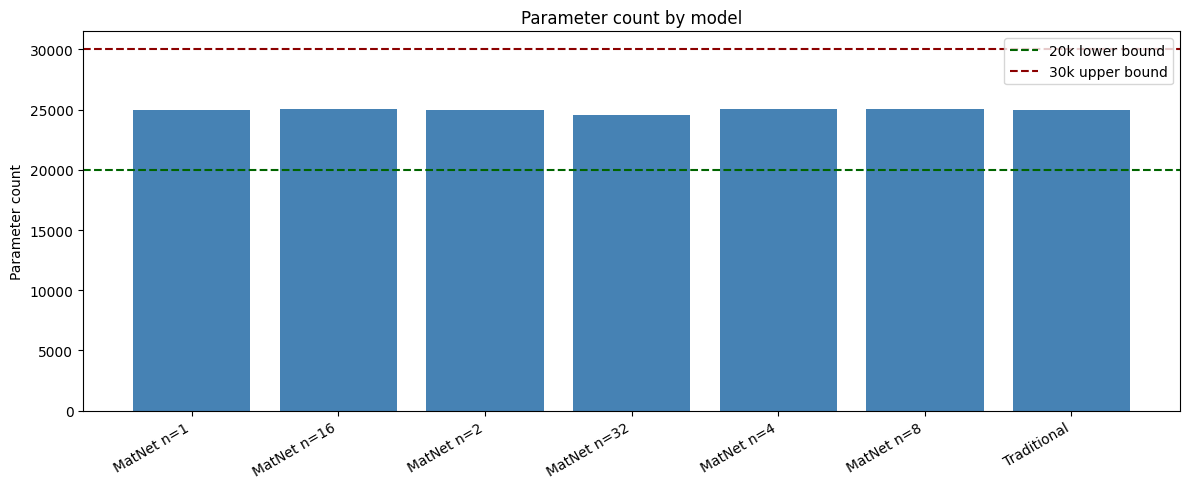

In [13]:
plot_df = results_df.copy()
plt.figure(figsize=(12, 5))
plt.bar(plot_df['model'], plot_df['param_count'], color='steelblue')
plt.axhline(TARGET_MIN, color='darkgreen', linestyle='--', label='20k lower bound')
plt.axhline(TARGET_MAX, color='darkred', linestyle='--', label='30k upper bound')
plt.xticks(rotation=30, ha='right')
plt.ylabel('Parameter count')
plt.title('Parameter count by model')
plt.legend()
plt.tight_layout()
plt.show()

## Plot 2: Test Accuracy

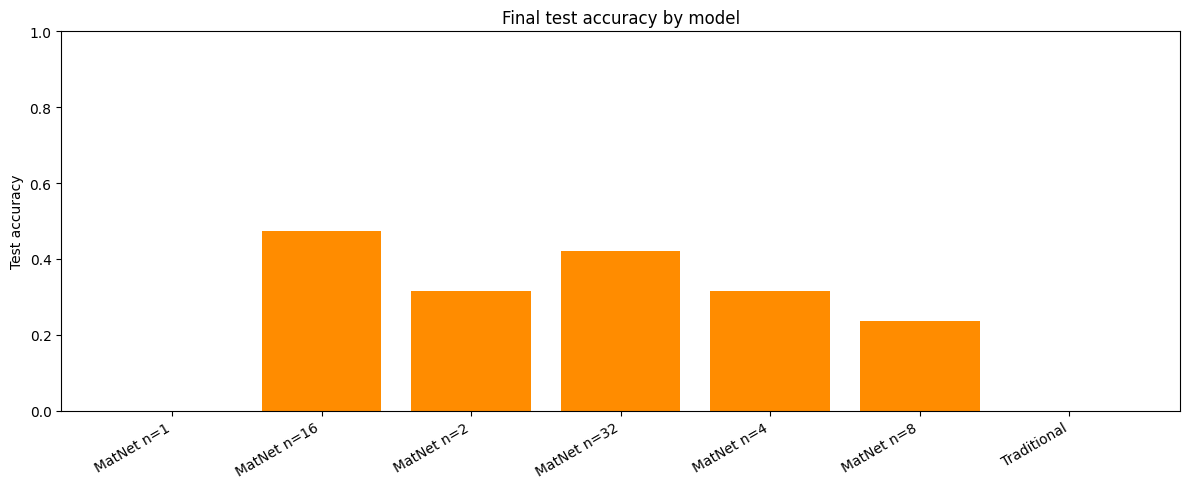

In [14]:
plt.figure(figsize=(12, 5))
plt.bar(plot_df['model'], plot_df['test_accuracy'], color='darkorange')
plt.xticks(rotation=30, ha='right')
plt.ylabel('Test accuracy')
plt.ylim(0.0, 1.0)
plt.title('Final test accuracy by model')
plt.tight_layout()
plt.show()

## Plot 3: Parameter Count vs Accuracy

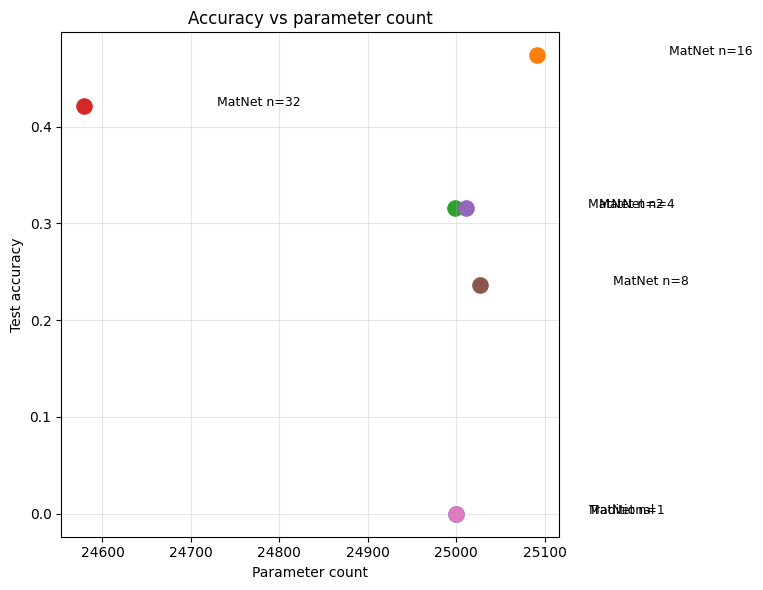

In [15]:
plt.figure(figsize=(8, 6))
for _, row in plot_df.iterrows():
    plt.scatter(row['param_count'], row['test_accuracy'], s=120)
    plt.text(row['param_count'] + 150, row['test_accuracy'], row['model'], fontsize=9)
plt.xlabel('Parameter count')
plt.ylabel('Test accuracy')
plt.title('Accuracy vs parameter count')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Plot 4: Test Accuracy Curves

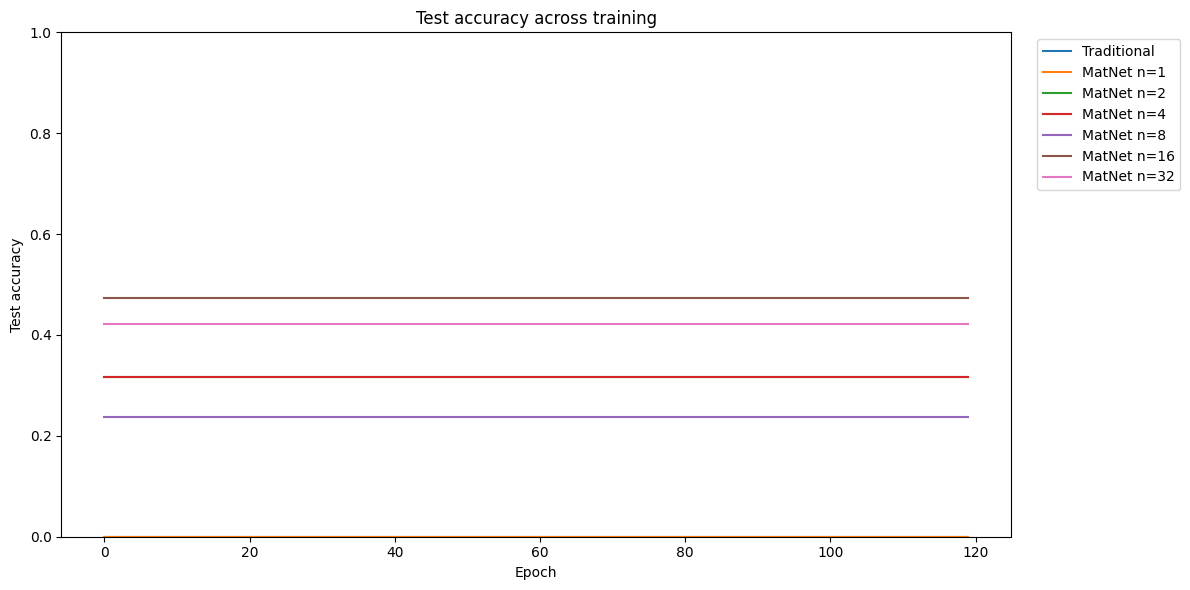

In [16]:
plt.figure(figsize=(12, 6))
for name, history in histories.items():
    plt.plot(history['test_acc'], label=name)
plt.xlabel('Epoch')
plt.ylabel('Test accuracy')
plt.ylim(0.0, 1.0)
plt.title('Test accuracy across training')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Result Table Sorted By Accuracy

In [17]:
results_df.sort_values(['test_accuracy', 'param_count'], ascending=[False, True]).reset_index(drop=True)

,model,n,hidden_dims,param_count,test_accuracy,test_loss
0,MatNet n=16,16,"(2, 3, 2, 12)",25091,0.473684,1.098606
1,MatNet n=32,32,"(1, 2, 1, 2)",24579,0.421053,1.098564
2,MatNet n=2,2,"(24, 20, 64, 64)",24999,0.315789,1.098606
3,MatNet n=4,4,"(32, 28, 10, 20)",25011,0.315789,1.098601
4,MatNet n=8,8,"(4, 10, 8, 20)",25027,0.236842,1.098622
5,MatNet n=1,1,"(24, 160, 80, 96)",25000,0.000000,1.098647
6,Traditional,dense,"(1, 24, 160, 80, 96)",25000,0.000000,1.189155
